In [7]:
from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/dataset/train"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine learning/FruitinAmazon.zip"
extract_path = "/content/FruitDataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Extraction completed!")

 Extraction completed!


In [9]:
train_dir = "/content/FruitDataset"

In [1]:
!pip install -q tensorflow

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [12]:
import os
print(os.listdir('/content/drive/MyDrive/AI and Machine learning'))

['Runway.jpg', 'Runway_BW.jpg', 'Untitled0.ipynb', 'mnist_0_and_1.csv', 'mnist_3_and_5.csv', 'Copy of devnagari digit.zip', 'DevanagariHandwrittenDigitDataset', 'FruitinAmazon.zip']


In [14]:
print(os.listdir('/content'))

['.config', 'dataset', 'drive', 'FruitDataset', 'sample_data']


In [15]:
import os
print(os.listdir('/content/FruitDataset'))

['FruitinAmazon']


In [16]:
train_dir = "/content/FruitDataset/FruitinAmazon"

In [17]:
import os

class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes:", class_names)

Found 2 classes: ['test', 'train']


In [19]:
train_dir = "/content/FruitDataset/FruitinAmazon/train"

In [20]:
import os

class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes:", class_names)

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [21]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','.jpeg'))]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k, v in class_counts.items():
    print(f"{k}: {v}")


Class Distribution:
acai: 15
cupuacu: 15
graviola: 15
guarana: 15
pupunha: 15
tucuma: 15


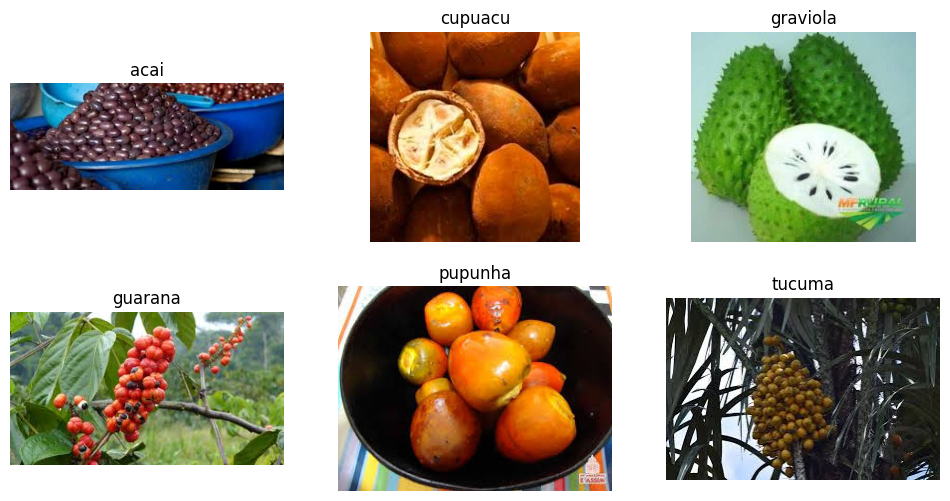

In [22]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = os.listdir(class_path)

    if images:
        img = os.path.join(class_path, random.choice(images))
        selected_images.append(img)
        selected_labels.append(class_name)

plt.figure(figsize=(12,6))

for i in range(len(selected_images)):
    img = mpimg.imread(selected_images[i])
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.show()

In [23]:
from tensorflow import keras

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=(224,224),
    batch_size=32,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [24]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

In [26]:
model = keras.Sequential([

    layers.Input(shape=(224,224,3)),

    # Augmentation + normalization
    data_augmentation,
    layers.Rescaling(1./255),

    # 🔹 Block 1
    layers.Conv2D(32, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 2
    layers.Conv2D(64, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # 🔹 Block 3
    layers.Conv2D(128, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Block 4 (extra for better accuracy)
    layers.Conv2D(256, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # 🔹 Classifier
    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output
    layers.Dense(len(class_names), activation='softmax')
])

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3),
]

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.1806 - loss: 2.3719 - val_accuracy: 0.0556 - val_loss: 1.8351 - learning_rate: 0.0010
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.2778 - loss: 1.8626 - val_accuracy: 0.2778 - val_loss: 1.7726 - learning_rate: 0.0010
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.4028 - loss: 1.6079 - val_accuracy: 0.1111 - val_loss: 1.8507 - learning_rate: 0.0010
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 9s/step - accuracy: 0.4167 - loss: 1.4185 - val_accuracy: 0.0556 - val_loss: 2.0154 - learning_rate: 0.0010
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.4861 - loss: 1.2068 - val_accuracy: 0.0556 - val_loss: 2.2116 - learning_rate: 0.0010
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step - accuracy: 0.5972 - loss: 1.0017 - val_accuracy: 0.0556 - val_loss: 2.3125 - learning_rate: 3.0000e-04
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5139 - loss: 1.2447 - val_accuracy: 0.0556 - v

In [30]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - accuracy: 0.2778 - loss: 1.7726
Validation Accuracy: 0.2778


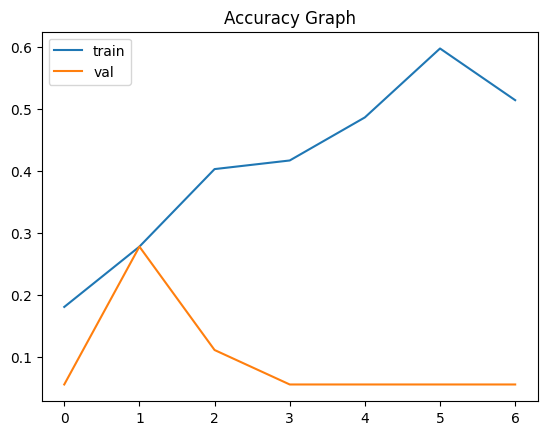

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy Graph")
plt.show()